In [1]:
import os

#add the root directory
os.chdir('../')

# Preprocessing: augment flamelet dataset with species scaled to logarithmic scale

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
path_data = "data-files/"
general_dataset_type = "Xu"
dataset_type = "flamelet"

header = "infer"

path_data_state_space = path_data + f"{general_dataset_type}-state-space-{dataset_type}.csv"
path_data_source = path_data + f"{general_dataset_type}-state-space_source-{dataset_type}.csv"
path_data_state_space_names = path_data + f"{general_dataset_type}-state-space-names.csv"
path_data_mf = path_data + f"{general_dataset_type}-mf-{dataset_type}.csv"
path_data_T = path_data + f"{general_dataset_type}-T-{dataset_type}.csv"

#load the data
data_state_space = pd.read_csv(path_data_state_space, header = header)
data_state_space_source = pd.read_csv(path_data_source, header = header)
data_state_space_names = pd.read_csv(path_data_state_space_names, header = header)
data_mf = pd.read_csv(path_data_mf, header = header)
data_T = pd.read_csv(path_data_T, header = header)

### Sanity check

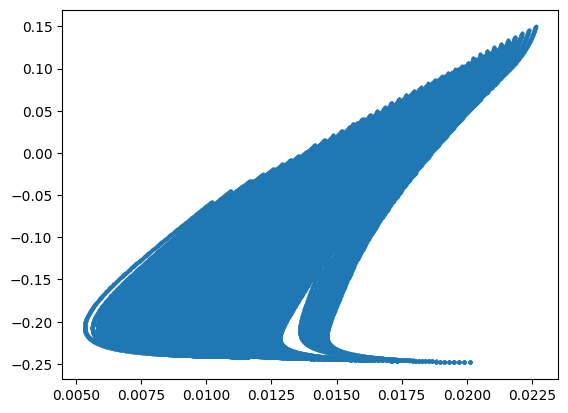

In [5]:
PV_heuristic = data_state_space["H2O"] - data_state_space["H2"] - data_state_space["O2"]

plt.scatter(data_mf, PV_heuristic, s = 3)
plt.show()

In [6]:
print(data_state_space)

               H2NN          H2O2       H2O        H2           HNO  \
0      0.000000e+00  0.000000e+00  0.000000  0.010167  0.000000e+00   
1     -3.818646e-32  6.537587e-10  0.000003  0.010065  1.067460e-16   
2     -2.430904e-32  2.191421e-09  0.000008  0.009968  3.571040e-16   
3      1.466470e-31  4.919736e-09  0.000016  0.009875  8.003399e-16   
4      5.123596e-31  9.087081e-09  0.000026  0.009786  1.476145e-15   
...             ...           ...       ...       ...           ...   
97795  1.022682e-16  3.928011e-07  0.195468  0.000199  1.105855e-09   
97796  9.544083e-17  3.517434e-07  0.195825  0.000180  1.075651e-09   
97797  8.782084e-17  3.103774e-07  0.196201  0.000160  1.064404e-09   
97798  7.804287e-17  2.639178e-07  0.196644  0.000137  1.230992e-09   
97799  7.371136e-17  2.459222e-07  0.196815  0.000127  1.793368e-09   

                HO2         HONO2          HONO             H          N2H3  \
0      0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000

### Detect which idx are zero and if it matches between the different species

In [9]:
for key in data_state_space_names.iloc[:, 0]:    
    count = (data_state_space[key] == 0).sum()
    zero_idx = data_state_space.index[data_state_space[key] == 0].tolist()
    print(f"{key}: {count}")
    print(zero_idx)

H2O2: 163
[0, 600, 1200, 1800, 2400, 3000, 3600, 4200, 4800, 5400, 6000, 6600, 7200, 7800, 8400, 9000, 9600, 10200, 10800, 11400, 12000, 12600, 13200, 13800, 14400, 15000, 15600, 16200, 16800, 17400, 18000, 18600, 19200, 19800, 20400, 21000, 21600, 22200, 22800, 23400, 24000, 24600, 25200, 25800, 26400, 27000, 27600, 28200, 28800, 29400, 30000, 30600, 31200, 31800, 32400, 33000, 33600, 34200, 34800, 35400, 36000, 36600, 37200, 37800, 38400, 39000, 39600, 40200, 40800, 41400, 42000, 42600, 43200, 43800, 44400, 45000, 45600, 46200, 46800, 47400, 48000, 48600, 49200, 49800, 50400, 51000, 51600, 52200, 52800, 53400, 54000, 54600, 55200, 55800, 56400, 57000, 57600, 58200, 58800, 59400, 60000, 60600, 61200, 61800, 62400, 63000, 63600, 64200, 64800, 65400, 66000, 66600, 67200, 67800, 68400, 69000, 69600, 70200, 70800, 71400, 72000, 72600, 73200, 73800, 74400, 75000, 75600, 76200, 76800, 77400, 78000, 78600, 79200, 79800, 80400, 81000, 81600, 82200, 82800, 83400, 84000, 84600, 85200, 85800, 86

### Remove rows with species mass fraction equal to zero

In [10]:
mask = ~(data_state_space == 0).any(axis=1)

In [12]:
false_idx = mask.index[~mask]
print(false_idx)

Index([    0,   600,  1200,  1800,  2400,  3000,  3600,  4200,  4800,  5400,
       ...
       91800, 92400, 93000, 93600, 94200, 94800, 95400, 96000, 96600, 97200],
      dtype='int64', length=163)


In [13]:
data_state_space = data_state_space.loc[mask]
data_state_space_source = data_state_space_source.loc[mask]
data_mf = data_mf.loc[mask]
data_T = data_T.loc[mask]

In [16]:
print(data_state_space.shape)
print(data_state_space_source.shape)
print(data_mf.shape)
print(data_T.shape)

(97637, 21)
(97637, 21)
(97637, 1)
(97637, 1)


In [17]:
print(data_state_space["H2O2"].min())
print(data_state_space["H2O"].min())
print(data_state_space["H2"].min())
print(data_state_space["HO2"].min())
print(data_state_space["N2O"].min())
print(data_state_space["NO2"].min())
print(data_state_space["NO"].min())
print(data_state_space["O2"].min())
print(data_state_space["OH"].min())

6.274287455e-10
2.530907318e-06
3.2544827111e-06
8.0842062699e-11
2.0813637513e-14
5.9279303412e-15
3.7397932332e-15
0.046781457769
5.0531980420000004e-18


### Augment with logarithmic species

In [18]:
filtered_state_space = data_state_space.copy()
filtered_mf = data_mf.copy()
filtered_T = data_T.copy()
filtered_state_space_source = data_state_space_source.copy()

filtered_state_space["logH2O2"] = np.log10(filtered_state_space["H2O2"])
filtered_state_space["logH2O"] = np.log10(filtered_state_space["H2O"])
filtered_state_space["logH2"] = np.log10(filtered_state_space["H2"])
filtered_state_space["logHO2"] = np.log10(filtered_state_space["HO2"])
filtered_state_space["logN2O"] = np.log10(filtered_state_space["N2O"])
filtered_state_space["logNO2"] = np.log10(filtered_state_space["NO2"])
filtered_state_space["logNO"] = np.log10(filtered_state_space["NO"])
filtered_state_space["logO2"] = np.log10(filtered_state_space["O2"])
filtered_state_space["logOH"] = np.log10(filtered_state_space["OH"])

print(filtered_state_space.shape)
print(filtered_state_space_source.shape)
print(filtered_mf.shape)
print(filtered_T.shape)

(97637, 30)
(97637, 21)
(97637, 1)
(97637, 1)


In [19]:
filtered_state_space.head()

,H2NN,H2O2,H2O,H2,HNO,HO2,HONO2,HONO,H,N2H3,...,O,logH2O2,logH2O,logH2,logHO2,logN2O,logNO2,logNO,logO2,logOH
1,-3.818646e-32,6.537587e-10,0.000003,0.010065,1.067460e-16,8.084206e-11,1.518609e-17,9.296548e-17,2.965497e-21,6.379879e-32,...,3.070275e-15,-9.184583,-5.524539,-1.997182,-10.092363,-13.414183,-14.174351,-14.427152,-0.637171,-17.296434
2,-2.430904e-32,2.191421e-09,0.000008,0.009968,3.571040e-16,2.699493e-10,6.717570e-17,3.773607e-16,8.603015e-21,2.358340e-31,...,8.953088e-15,-8.659274,-5.078957,-2.001404,-9.568718,-12.828813,-13.576125,-13.912727,-0.637109,-16.828543
3,1.466470e-31,4.919736e-09,0.000016,0.009875,8.003399e-16,6.040927e-10,1.921215e-16,1.000020e-15,1.691324e-20,5.758718e-31,...,1.763304e-14,-8.308058,-4.794163,-2.005471,-9.218896,-12.425797,-13.161864,-13.570726,-0.637052,-16.528558
4,5.123596e-31,9.087081e-09,0.000026,0.009786,1.476145e-15,1.112804e-09,4.378640e-16,2.131642e-15,2.786407e-20,1.143300e-30,...,2.898303e-14,-8.041576,-4.583643,-2.009387,-8.953581,-12.114714,-12.841012,-13.312070,-0.636998,-16.304025
5,1.307504e-30,1.488634e-08,0.000038,0.009702,2.415187e-15,1.818859e-09,8.620098e-16,3.956140e-15,4.146642e-20,1.993948e-30,...,4.283274e-14,-7.827212,-4.417162,-2.013159,-8.740201,-11.861599,-12.579358,-13.104427,-0.636948,-16.122224


In [20]:
column_names = np.array(filtered_state_space.columns)
state_space_names_augm = pd.DataFrame(column_names)
print(state_space_names_augm)

          0
0      H2NN
1      H2O2
2       H2O
3        H2
4       HNO
5       HO2
6     HONO2
7      HONO
8         H
9      N2H3
10      N2O
11       N2
12      NH2
13       NH
14      NNH
15      NO2
16       NO
17        N
18       O2
19       OH
20        O
21  logH2O2
22   logH2O
23    logH2
24   logHO2
25   logN2O
26   logNO2
27    logNO
28    logO2
29    logOH


In [21]:
filtered_state_space.to_csv('data-files/Xu-state-space-flamelet-augm.csv', index=False)
filtered_state_space_source.to_csv('data-files/Xu-state-space_source-flamelet-augm.csv', index=False)
filtered_T.to_csv('data-files/Xu-T-flamelet-augm.csv', index=False)
filtered_mf.to_csv('data-files/Xu-mf-flamelet-augm.csv', index=False)

In [22]:
state_space_names_augm.to_csv(f'data-files/Xu-state-space-names-flamelet-augm.csv', header=False, index=False)